# Qudit-Mediated SWAP Sweep

Loads the aggregated sweep files and produces:
1. Fidelity vs evolution time T (d=2 and d=4)
2. Quantum speed limit identification
3. Convergence heatmap (restarts × T)
4. Loss curves at selected T values
5. Restart fidelity distributions
6. Optimal pulse shapes at the speed limit
7. Generator importance

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec

plt.rcParams.update({
    "figure.dpi": 130,
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

d2 = np.load("results/d2/d2_sweep.npz", allow_pickle=True)
d4 = np.load("results/d4/d4_sweep.npz", allow_pickle=True)

T2, F2 = d2["T_values"], d2["fidelities"]
T4, F4 = d4["T_values"], d4["fidelities"]

# all_loss_histories: (n_T, n_restarts, epochs)  — stored as loss = 1 - fidelity
H2 = d2["all_loss_histories"]   # (50, 50, 4000)
H4 = d4["all_loss_histories"]

omega2 = d2["best_omegas"]      # (50, M, 27)
omega4 = d4["best_omegas"]

labels2 = list(d2["generator_labels"])
labels4 = list(d4["generator_labels"])

print(f"d=2: T in [{T2.min():.2f}, {T2.max():.2f}], max fidelity = {F2.max():.4f}")
print(f"d=4: T in [{T4.min():.2f}, {T4.max():.2f}], max fidelity = {F4.max():.4f}")

d=2: T in [0.30, 12.00], max fidelity = 0.3309
d=4: T in [0.30, 15.00], max fidelity = 0.2909


## 1. Fidelity vs Evolution Time

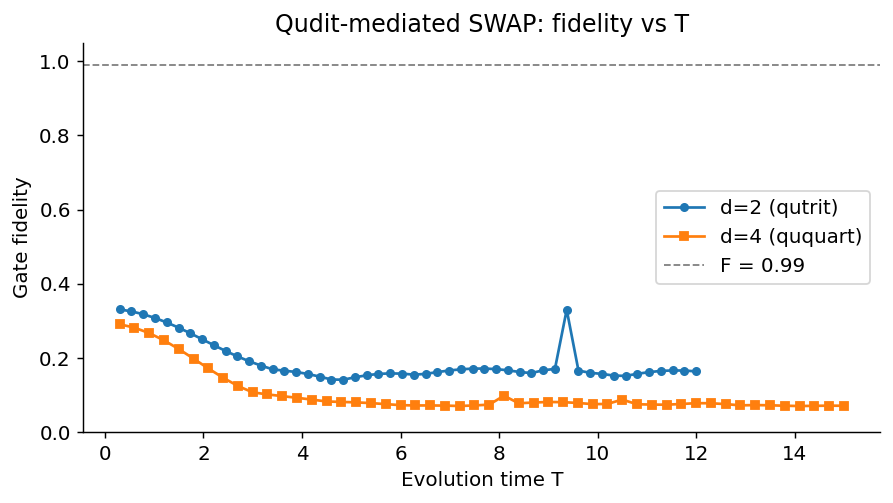

Quantum speed limit (F ≥ 0.99):
  d=2: T = None
  d=4: T = None


In [3]:
THRESHOLD = 0.99

def speed_limit(T, F, threshold=THRESHOLD):
    idx = np.argmax(F >= threshold)
    return T[idx] if F[idx] >= threshold else None

qsl2 = speed_limit(T2, F2)
qsl4 = speed_limit(T4, F4)

fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(T2, F2, "o-", ms=4, lw=1.5, color="C0", label="d=2 (qutrit)")
ax.plot(T4, F4, "s-", ms=4, lw=1.5, color="C1", label="d=4 (ququart)")

ax.axhline(THRESHOLD, color="gray", lw=1, ls="--", label=f"F = {THRESHOLD}")

for qsl, color, tag in [(qsl2, "C0", "d=2"), (qsl4, "C1", "d=4")]:
    if qsl is not None:
        ax.axvline(qsl, color=color, lw=1, ls=":")
        ax.text(qsl + 0.05, 0.05, f"QSL ({tag})\nT={qsl:.2f}",
                color=color, fontsize=9, va="bottom")

ax.set_xlabel("Evolution time T")
ax.set_ylabel("Gate fidelity")
ax.set_title("Qudit-mediated SWAP: fidelity vs T")
ax.legend()
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig("results/fidelity_vs_T.pdf", bbox_inches="tight")
plt.show()

print(f"Quantum speed limit (F ≥ {THRESHOLD}):")
print(f"  d=2: T = {qsl2}")
print(f"  d=4: T = {qsl4}")
if qsl2 and qsl4:
    ratio = qsl4 / qsl2
    print(f"  Ratio d4/d2 = {ratio:.3f}  ({'faster' if ratio < 1 else 'slower'} with d=4)")

## 2. Restart Fidelity Distributions (violin plots)

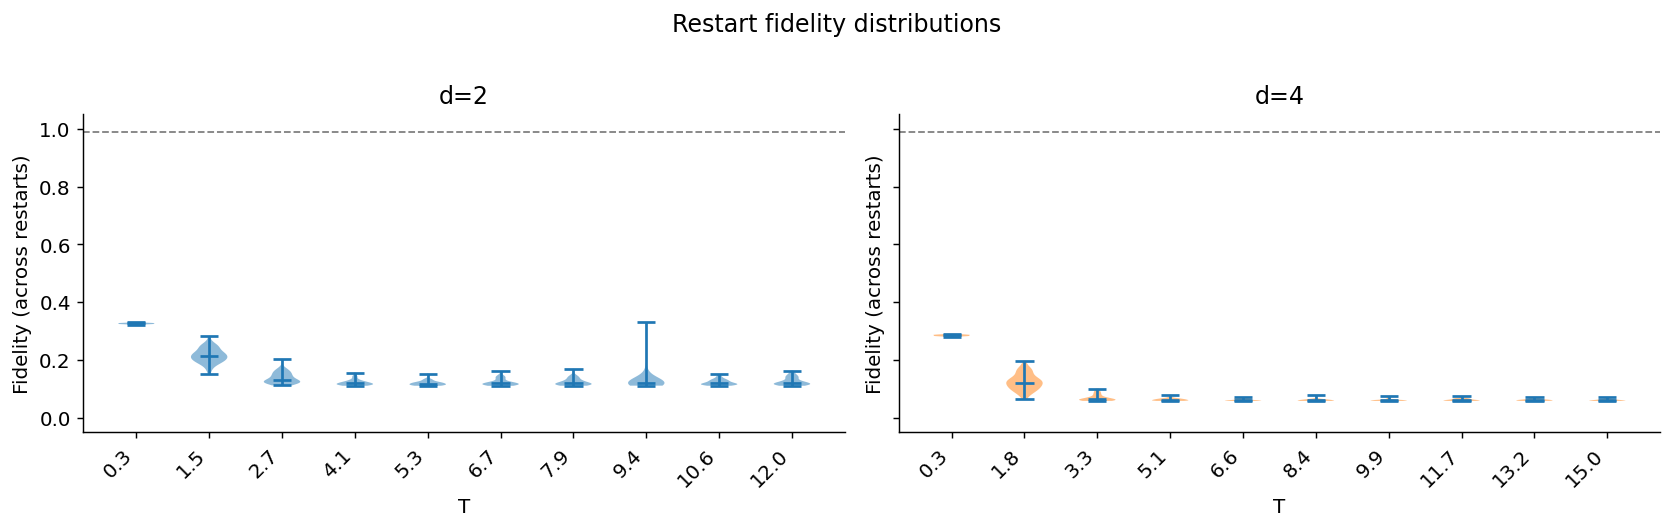

In [4]:
# Final fidelity per restart = 1 - final loss
final_fid2 = 1.0 - H2[:, :, -1]   # (50, 50)
final_fid4 = 1.0 - H4[:, :, -1]

# Subsample T indices evenly for readability
n_show = 10
idx2 = np.linspace(0, len(T2) - 1, n_show, dtype=int)
idx4 = np.linspace(0, len(T4) - 1, n_show, dtype=int)

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)

for ax, final_fid, T, idx, color, title in [
    (axes[0], final_fid2, T2, idx2, "C0", "d=2"),
    (axes[1], final_fid4, T4, idx4, "C1", "d=4"),
]:
    data = [final_fid[i] for i in idx]
    parts = ax.violinplot(data, positions=range(n_show), showmedians=True,
                          showextrema=True)
    for pc in parts["bodies"]:
        pc.set_facecolor(color)
        pc.set_alpha(0.5)
    ax.set_xticks(range(n_show))
    ax.set_xticklabels([f"{T[i]:.1f}" for i in idx], rotation=45, ha="right")
    ax.set_xlabel("T")
    ax.set_ylabel("Fidelity (across restarts)")
    ax.set_title(title)
    ax.axhline(THRESHOLD, color="gray", lw=1, ls="--")
    ax.set_ylim(-0.05, 1.05)

plt.suptitle("Restart fidelity distributions", y=1.01)
plt.tight_layout()
plt.savefig("results/restart_distributions.pdf", bbox_inches="tight")
plt.show()

## 3. Convergence Heatmap (best loss per restart at each T)

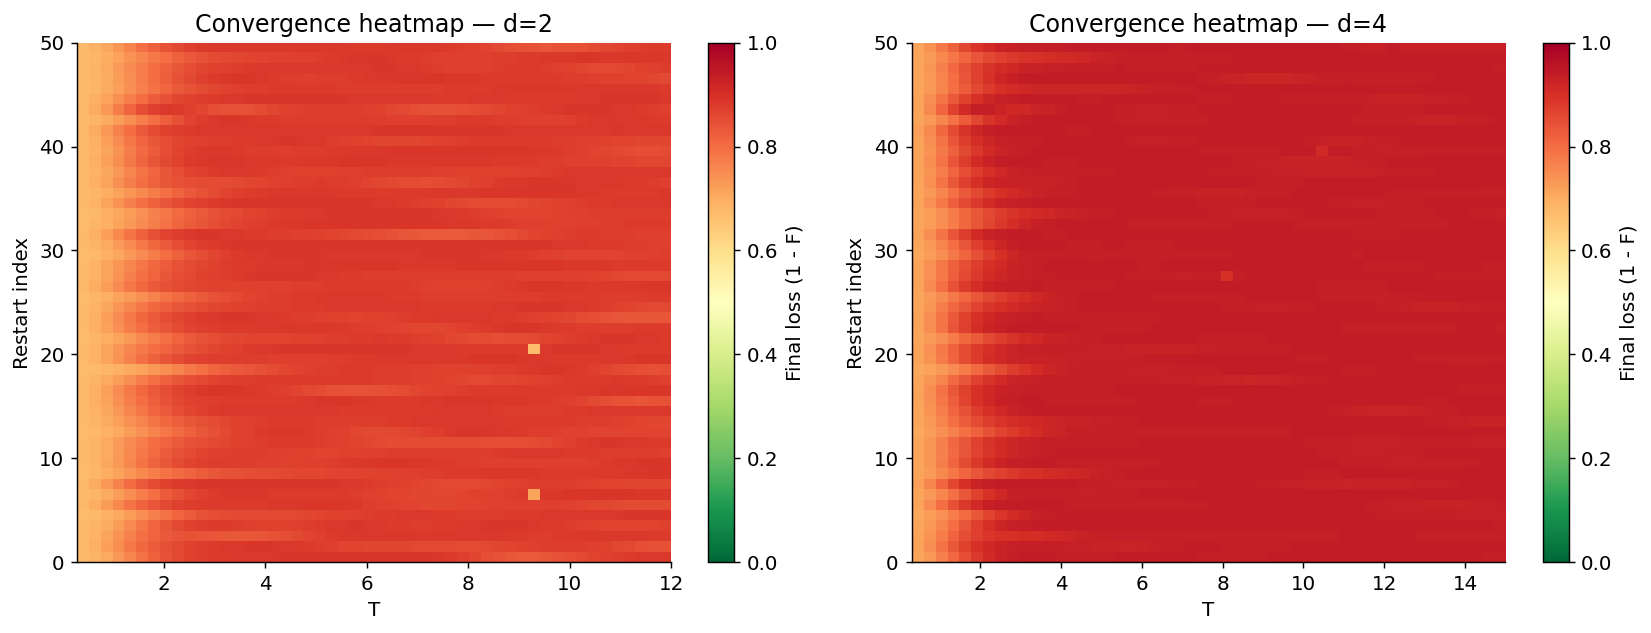

In [5]:
# best_final_loss[T_idx, restart] = H[T_idx, restart, -1]
best_loss2 = H2[:, :, -1]   # (50, 50)
best_loss4 = H4[:, :, -1]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, loss, T, title in [
    (axes[0], best_loss2, T2, "d=2"),
    (axes[1], best_loss4, T4, "d=4"),
]:
    im = ax.imshow(
        loss.T,                      # (restarts, T)
        aspect="auto",
        origin="lower",
        cmap="RdYlGn_r",
        vmin=0, vmax=1,
        extent=[T.min(), T.max(), 0, loss.shape[1]],
    )
    fig.colorbar(im, ax=ax, label="Final loss (1 - F)")
    ax.set_xlabel("T")
    ax.set_ylabel("Restart index")
    ax.set_title(f"Convergence heatmap — {title}")

plt.tight_layout()
plt.savefig("results/convergence_heatmap.pdf", bbox_inches="tight")
plt.show()

## 4. Loss Curves at Selected T Values

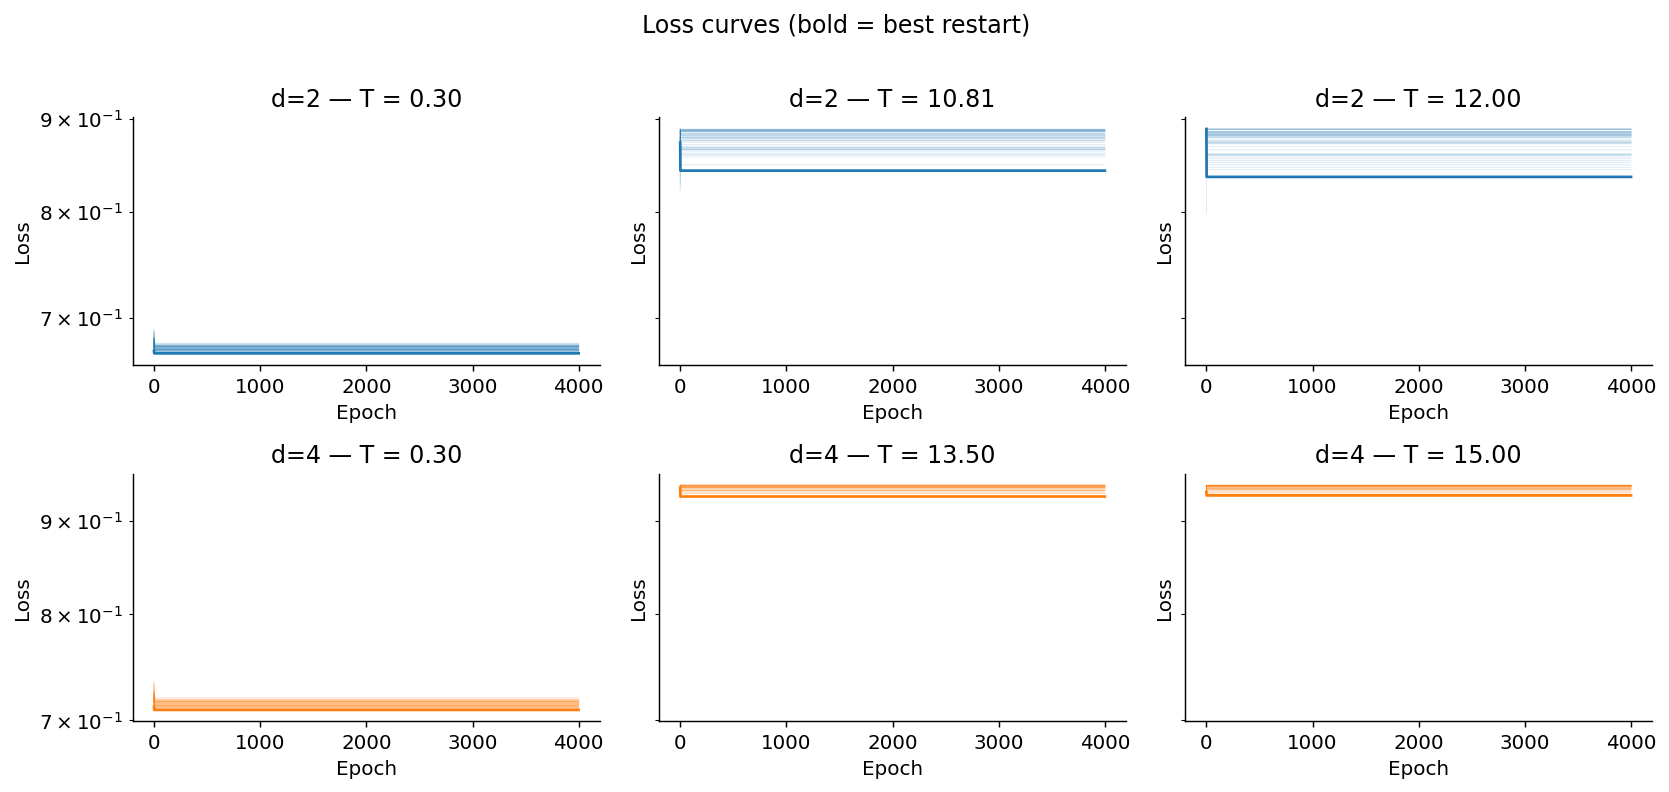

In [6]:
def plot_loss_curves(ax, H, T, T_idx, color, alpha_individual=0.15):
    """Plot all restart loss curves for a single T, plus the best one."""
    curves = H[T_idx]   # (n_restarts, epochs)
    epochs = np.arange(curves.shape[1])
    best_restart = np.argmin(curves[:, -1])
    for i, c in enumerate(curves):
        lw = 1.5 if i == best_restart else 0.5
        a  = 1.0 if i == best_restart else alpha_individual
        ax.semilogy(epochs, c, lw=lw, alpha=a, color=color)
    ax.set_title(f"T = {T[T_idx]:.2f}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")

# Pick T values: near start, near speed limit, and near end
def pick_indices(T, F, n=4):
    qsl_idx = np.argmax(F >= THRESHOLD) if np.any(F >= THRESHOLD) else len(T) - 1
    candidates = sorted(set([
        0,
        max(0, qsl_idx - 5),
        qsl_idx,
        len(T) - 1,
    ]))
    return candidates[:n]

idx2 = pick_indices(T2, F2)
idx4 = pick_indices(T4, F4)

fig, axes = plt.subplots(2, len(idx2), figsize=(13, 6), sharey="row")

for col, ti in enumerate(idx2):
    plot_loss_curves(axes[0, col], H2, T2, ti, "C0")
for col, ti in enumerate(idx4):
    plot_loss_curves(axes[1, col], H4, T4, ti, "C1")

for ax in axes[0]:
    ax.set_title("d=2 — " + ax.get_title())
for ax in axes[1]:
    ax.set_title("d=4 — " + ax.get_title())

plt.suptitle("Loss curves (bold = best restart)", y=1.01)
plt.tight_layout()
plt.savefig("results/loss_curves.pdf", bbox_inches="tight")
plt.show()

## 5. Optimal Pulse Shapes at the Speed Limit

ValueError: Invalid format specifier '.4f if tag=='d=2' else F4[qi]:.4f' for object of type 'float'

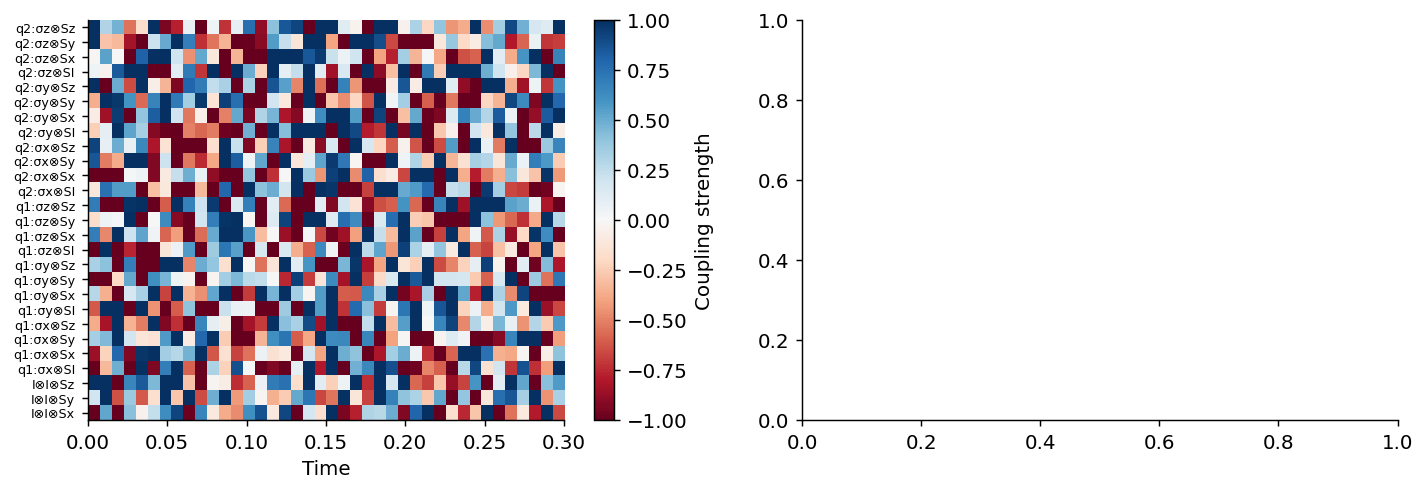

In [7]:
def qsl_idx(T, F):
    idx = np.argmax(F >= THRESHOLD)
    return idx if F[idx] >= THRESHOLD else np.argmax(F)

qi2 = qsl_idx(T2, F2)
qi4 = qsl_idx(T4, F4)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, omega, labels, T, qi, color, tag in [
    (axes[0], omega2, labels2, T2, qi2, "C0", "d=2"),
    (axes[1], omega4, labels4, T4, qi4, "C1", "d=4"),
]:
    pulse = omega[qi]          # (M, 27)
    M = pulse.shape[0]
    t = np.linspace(0, float(T[qi]), M)
    im = ax.imshow(
        pulse.T,               # (generators, time steps)
        aspect="auto",
        origin="lower",
        cmap="RdBu",
        vmin=-1, vmax=1,
        extent=[0, float(T[qi]), -0.5, pulse.shape[1] - 0.5],
    )
    fig.colorbar(im, ax=ax, label="Coupling strength")
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels, fontsize=7)
    ax.set_xlabel("Time")
    ax.set_title(f"{tag} — optimal pulse at T={T[qi]:.2f} (F={F2[qi]:.4f if tag=='d=2' else F4[qi]:.4f})")

plt.tight_layout()
plt.savefig("results/optimal_pulses.pdf", bbox_inches="tight")
plt.show()

## 6. Generator Importance (RMS coupling strength)

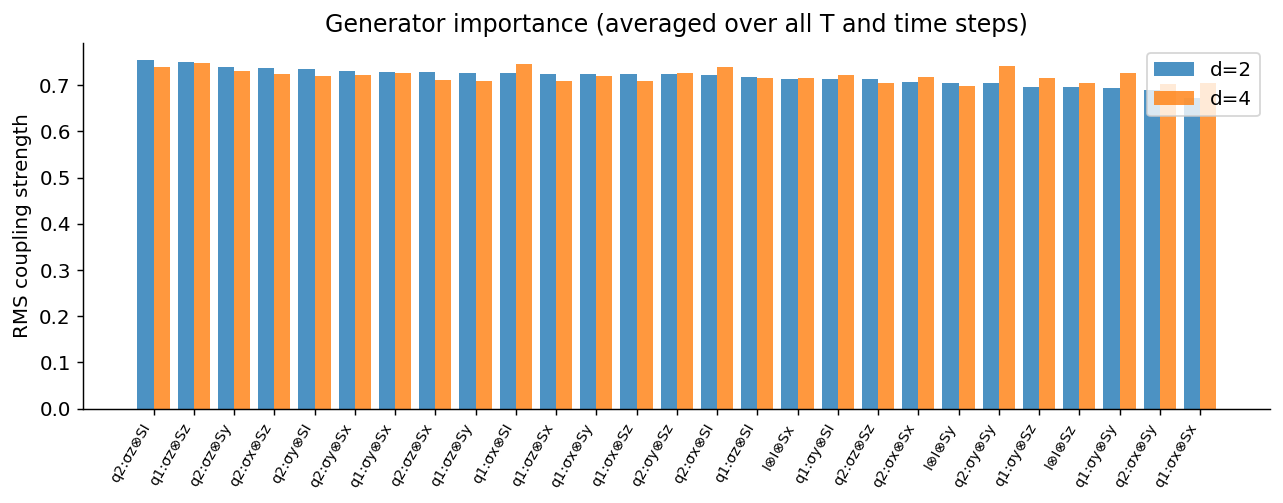

In [8]:
# Average |omega| across time steps, aggregated over all T values
rms2 = np.sqrt(np.mean(omega2 ** 2, axis=(0, 1)))  # (27,)
rms4 = np.sqrt(np.mean(omega4 ** 2, axis=(0, 1)))

# Sort by d=2 importance
order = np.argsort(rms2)[::-1]

fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(labels2))
width = 0.4
ax.bar(x - width/2, rms2[order], width, label="d=2", color="C0", alpha=0.8)
ax.bar(x + width/2, rms4[order], width, label="d=4", color="C1", alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels([labels2[i] for i in order], rotation=60, ha="right", fontsize=8)
ax.set_ylabel("RMS coupling strength")
ax.set_title("Generator importance (averaged over all T and time steps)")
ax.legend()
plt.tight_layout()
plt.savefig("results/generator_importance.pdf", bbox_inches="tight")
plt.show()

## 7. Summary Table

In [9]:
print("=" * 50)
print("SWEEP SUMMARY")
print("=" * 50)
for tag, T, F, H in [("d=2", T2, F2, H2), ("d=4", T4, F4, H4)]:
    qsl = speed_limit(T, F)
    n_converged = np.sum(F >= THRESHOLD)
    print(f"\n{tag}:")
    print(f"  T range:        [{T.min():.2f}, {T.max():.2f}]  ({len(T)} points)")
    print(f"  Max fidelity:   {F.max():.4f} at T = {T[np.argmax(F)]:.3f}")
    print(f"  Speed limit:    {qsl if qsl else 'not reached (F never >= threshold)'}")
    print(f"  T points ≥ {THRESHOLD}: {n_converged} / {len(T)}")
    best_per_T = 1.0 - H[:, :, -1].min(axis=1)   # best restart fidelity per T
    print(f"  Avg best fid:   {best_per_T.mean():.4f}")
    # Restart success rate at the speed-limit T
    if qsl:
        qi = np.argmax(F >= THRESHOLD)
        restarts_above = np.sum(1.0 - H[qi, :, -1] >= THRESHOLD)
        print(f"  Restarts reaching threshold at QSL T: {restarts_above} / {H.shape[1]}")

SWEEP SUMMARY

d=2:
  T range:        [0.30, 12.00]  (50 points)
  Max fidelity:   0.3309 at T = 0.300
  Speed limit:    not reached (F never >= threshold)
  T points ≥ 0.99: 0 / 50
  Avg best fid:   0.1902

d=4:
  T range:        [0.30, 15.00]  (50 points)
  Max fidelity:   0.2909 at T = 0.300
  Speed limit:    not reached (F never >= threshold)
  T points ≥ 0.99: 0 / 50
  Avg best fid:   0.1036


## 8. Sequential SWAP Structure Analysis

Tests the hypothesis that the optimal protocol is a **sequential SWAP**:
1. First half of segments: SWAP(qubit₁, ancilla) ⊗ I(qubit₂)
2. Second half: I(qubit₁) ⊗ SWAP(qubit₂, ancilla)

Net effect: SWAP(qubit₁, qubit₂) with ancilla restored to |0⟩.

For **d=4** we additionally check whether T* ≈ 2 × 3π/4 = 3π/2 ≈ 4.712 (the Mandelstam–Tamm bound for two qubit–qudit SWAPs), and use a partial-trace / block structure to isolate the qubit₁ ⊗ ancilla unitary.

In [ ]:
# Load precomputed analysis (produced by --mode analyze on the cluster)
a2 = np.load("results/d2/d2_analysis.npz", allow_pickle=True)
a4 = np.load("results/d4/d4_analysis.npz", allow_pickle=True)

T_a2 = a2["T_values"]
U_halves2 = a2["U_halves"]                          # (n_T, 8, 8)  complex
half_fids2 = a2["half_fidelities_vs_swap_q1_anc"]   # (n_T,)

qi2 = int(np.argmax(half_fids2))
print(f"d=2  best half-fidelity vs SWAP(q1,anc)⊗I(q2): "
      f"{half_fids2[qi2]:.6f}  at T={T_a2[qi2]:.4f}")
print(f"  (speed-limit T* from fidelity sweep: T={float(T2[int(np.argmax(F2 >= THRESHOLD))]):.4f})")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, U, title in [
    (axes[0], np.abs(U_halves2[qi2]),  f"|U_half| at T={T_a2[qi2]:.2f}"),
    (axes[1], np.abs(np.array([       # SWAP(q1,anc)⊗I(q2) reference
        [1,0,0,0,0,0,0,0],
        [0,1,0,0,0,0,0,0],
        [0,0,1,0,0,0,0,0],
        [0,0,0,1,0,0,0,0],
        [0,0,0,0,0,0,1,0],  # |1,0,0⟩ → |0,0,1⟩
        [0,0,0,0,0,1,0,0],
        [0,0,0,0,1,0,0,0],  # |0,0,1⟩ → |1,0,0⟩
        [0,0,0,0,0,0,0,1],
    ], dtype=float)), "SWAP(q1,anc)⊗I(q2)"),
]:
    im = ax.imshow(U, cmap="Blues", vmin=0, vmax=1)
    ax.set_title(title)
    fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig("results/half_unitary_d2.pdf", bbox_inches="tight")
plt.show()

# Fidelity of first-half unitary vs SWAP(q1,anc) across all T
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(T_a2, half_fids2, "o-", ms=4, color="C0")
ax.axhline(THRESHOLD, color="gray", lw=1, ls="--", label=f"F={THRESHOLD}")
ax.set_xlabel("T")
ax.set_ylabel("Half-protocol fidelity\nvs SWAP(q1,anc)⊗I(q2)")
ax.set_title("d=2: Is the first half a qubit–ancilla SWAP?")
ax.legend()
plt.tight_layout()
plt.savefig("results/half_fidelity_d2.pdf", bbox_inches="tight")
plt.show()

In [ ]:
MT_BOUND = 2 * 3 * np.pi / 4   # 3π/2 ≈ 4.712

T_a4        = a4["T_values"]
U_halves4   = a4["U_halves"]        # (n_T, 16, 16) complex
V_halves4   = a4["V_halves"]        # (n_T, 8, 8)  extracted q1⊗anc unitary
block_diffs = a4["half_block_diffs"] # (n_T,)  max|V_j0 - V_j1|

qi4 = int(np.argmax(F4 >= THRESHOLD)) if np.any(F4 >= THRESHOLD) else int(np.argmax(F4))
T_star4 = float(T4[qi4])

print(f"d=4 speed limit: T* = {T_star4:.4f}  (MT bound = {MT_BOUND:.4f},  ratio = {T_star4/MT_BOUND:.3f})")

# Block structure: how close is U_half to V_{q1,anc} ⊗ I_{q2}?
qi_block = int(np.argmin(block_diffs))
print(f"\nBest block structure at T={T_a4[qi_block]:.4f}: max|V_j0-V_j1| = {block_diffs[qi_block]:.6f}")
print(f"  (speed-limit index has block diff = {block_diffs[qi4]:.6f})")

print(f"\n|V_{{q1,anc}}| at speed-limit T (rounded to 2 d.p.):")
print(np.round(np.abs(V_halves4[qi4]), 2))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

im0 = axes[0].imshow(np.abs(U_halves4[qi4]), cmap="Blues", vmin=0, vmax=1)
axes[0].set_title(f"|U_half| at T*={T_star4:.2f}")
fig.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(np.abs(V_halves4[qi4]), cmap="Blues", vmin=0, vmax=1)
axes[1].set_title("|V_{q1,anc}| (j=0 block)")
fig.colorbar(im1, ax=axes[1])

im2 = axes[2].imshow(block_diffs[:, None], cmap="Reds", aspect="auto")
axes[2].set_yticks(range(len(T_a4)))
axes[2].set_yticklabels([f"{t:.1f}" for t in T_a4], fontsize=6)
axes[2].set_xticks([])
axes[2].set_ylabel("T")
axes[2].set_title("Block diff |V_j0-V_j1| vs T\n(0 → perfect V⊗I structure)")
fig.colorbar(im2, ax=axes[2])

plt.tight_layout()
plt.savefig("results/half_unitary_d4.pdf", bbox_inches="tight")
plt.show()